In [202]:
! pip install "numpy<2.0,>=1.20"
! pip install --upgrade shap scipy

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


In [203]:
! pip install shap

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', None)

## Load Data

In [205]:
# Load data
df_pan = pd.read_csv("../datasets/final_data/pan_final.csv")
df_sandal = pd.read_csv("../datasets/final_data/sandal_final.csv")
df_sunscreen = pd.read_csv("../datasets/final_data/sunscreen_final.csv")
df_wallet = pd.read_csv("../datasets/final_data/wallet_final.csv")

## Config

In [206]:
import numpy as np

import os
import random
import numpy as np

def set_global_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "val_size": 0.2,
    "cv_folds": 5,
    "stage2_trials": 100,

    "target_cols": ["z_sold", "z_rating_credibility"],
    "metrics": ["rmse", "mae", "r2"],

    "selection_metric": "rmse",
    "include_ensemble_in_selection": True,

    # new flags
    "use_test_evaluation": False,
    "report_test_metrics": False,
    "primary_report_metric": "validation_rmse"
}

## Data Split

In [207]:
from sklearn.model_selection import train_test_split

val_relative = CONFIG["val_size"] / (1 - CONFIG["test_size"])

def split_data(df, config):
    train_val, test = train_test_split(
        df,
        test_size=config["test_size"],
        random_state=config["random_seed"]
    )

    train, val = train_test_split(
        train_val,
        test_size=val_relative,
        random_state=config["random_seed"]
    )
    return train, val, test

## Feature Type Detection

In [208]:
def detect_feature_types(df):
    numeric = []
    categorical = []
    binary = []

    for col in df.columns:

        # skip ID-like columns where it has many unique values as rows
        if df[col].dtype == "object" and df[col].nunique() > 0.9 * len(df):
            continue
        
        # detect binary features (usually contains 0 or 1)
        if df[col].nunique() == 2: 
            binary.append(col)

        # convert to numeric if possible
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric.append(col)

        else:
            categorical.append(col)

    return numeric, categorical, binary

def select_features(df):
    cols = df.columns.tolist()

    drop_cols = {
        "target",
        "title",
        "sold",
        "reviews",
        "gmv_cal",
        "rating",
        "rating_credibility",
        "z_sold",
        "z_rating_credibility",
        "id",
        "seller_name"
    }

    drop_log_related = {
        "log_sold",
        "log_reviews",
        "log_gmv_cal"
    }

    selected = []

    for c in cols:
        if c in drop_cols or c in drop_log_related:
            continue

        selected.append(c)

    return selected

## Feature Split (Between Log and Non-Log)

In [209]:
def split_features_by_model(df, num_cols):

    log_cols = [c for c in num_cols if c.startswith("log_")]

    raw_cols = []
    for c in log_cols:
        raw = c.replace("log_", "")
        if raw in df.columns:
            raw_cols.append(raw)

    # numeric that are not log or raw pairs
    other_numeric = [
        c for c in num_cols
        if not c.startswith("log_") and c not in raw_cols
    ]

    return log_cols, raw_cols, other_numeric

## Target Engine (PCA + Bootstrap)

In [210]:
from sklearn.decomposition import PCA

def bootstrap_pca_weights(train, cols, n_boot=200, random_seed=42):
    rng = np.random.default_rng(random_seed)
    weights = []

    X = train[cols].values

    for _ in range(n_boot):
        # sample row of X
        idx = rng.choice(len(X), len(X), replace=True)
        sample = X[idx]

        # fit PCA on sample
        pca = PCA(n_components=1)
        pca.fit(sample)

        w = pca.components_[0]

        # Align sign
        if w[0] < 0:
            w = -w

        weights.append(w)

    weights = np.array(weights)

    mean_w = weights.mean(axis=0)
    std_w = weights.std(axis=0)

    return mean_w, std_w


def create_target(df, weights, cols):
    return df[cols].values @ weights

## Preprocessing Pipelines

In [211]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate the columns for linear and tree models
# Convert categorical features to one-hot encoding for model that can't process categorical features directly
def build_linear_pipeline(df, num_cols, cat_cols):

    log_cols, _, other_numeric = split_features_by_model(df, num_cols)

    linear_num_cols = log_cols + other_numeric

    print("\n[DEBUG] Linear features:")
    print(linear_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, linear_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])


def build_tree_pipeline(df, num_cols, cat_cols):

    log_cols, raw_cols, other_numeric = split_features_by_model(df, num_cols)

    tree_num_cols = raw_cols + other_numeric

    print("\n[DEBUG] Tree features:")
    print(tree_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, tree_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

## List of Models

In [212]:
! pip install xgboost lightgbm catboost

In [213]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor


def get_models():
    return {
        # Linear models
        "linear_regression": LinearRegression(),
        "ridge": Ridge(),
        "lasso": Lasso(),
        "elastic_net": ElasticNet(),

        # Tree models
        "random_forest": RandomForestRegressor(random_state=CONFIG["random_seed"]),
        "extra_trees": ExtraTreesRegressor(random_state=CONFIG["random_seed"]),

        # Boosting models
        "xgboost": xgb.XGBRegressor(
            tree_method="hist",
            random_state=CONFIG["random_seed"],
            n_jobs=1
        ),
        "lightgbm": lgb.LGBMRegressor(
            verbosity=-1,
            random_state=CONFIG["random_seed"],
            n_jobs=1
        ),
        "catboost": CatBoostRegressor(
            verbose=0,
            random_seed=CONFIG["random_seed"],
            thread_count=1
        ),

        # Optional additional models
        # "svr": SVR(),
        # "knn": KNeighborsRegressor(),
    }

## Evaluation Metrics

In [214]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

## Stage 1 - Fast Screening

In [215]:
from sklearn.model_selection import cross_validate

def stage1_search(models, X, y, preprocessors, config):

    results = []
    cv_splitter = get_cv_splitter(config)

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    for name, model in models.items():

        pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=cv_splitter,
            scoring=scoring,
            return_train_score=False
        )

        results.append({
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_sd": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean()
        })

    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean")
    top_models = results_df.head(3).to_dict("records")

    return top_models, results_df

## Stage 2 - Optuna Tuning

In [216]:
! pip install optuna

In [217]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def tune_model(model_name, X, y, preprocessor, config):

    cv_splitter = get_cv_splitter(config)

    def objective(trial):

        # Linear Models
        if model_name == "linear_regression":
            model = LinearRegression()

        elif model_name == "ridge":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)
            }
            model = Ridge(**params)

        elif model_name == "lasso":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)
            }
            model = Lasso(**params)

        elif model_name == "elastic_net":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
                "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
            }
            model = ElasticNet(**params)

        # Tree Models
        elif model_name == "random_forest":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
            }
            model = RandomForestRegressor(**params, random_state=CONFIG["random_seed"])

        elif model_name == "extra_trees":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
            }
            model = ExtraTreesRegressor(**params, random_state=CONFIG["random_seed"])

        # Boosting Models
        elif model_name == "xgboost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)
            }
            model = xgb.XGBRegressor(
                tree_method="hist",
                random_state=CONFIG["random_seed"],
                **params
            )

        elif model_name == "lightgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
                "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 50)
            }
            model = lgb.LGBMRegressor(
                **params,
                verbosity=-1,
                random_state=CONFIG["random_seed"]
            )

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 800),
                "depth": trial.suggest_int("depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "border_count": trial.suggest_int("border_count", 32, 255)
            }
            model = CatBoostRegressor(
                **params,
                verbose=0,
                random_seed=CONFIG["random_seed"]
            )

        # SVR
        elif model_name == "svr":
            params = {
                "C": trial.suggest_float("C", 0.1, 100, log=True),
                "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
            }
            model = SVR(**params)

        # KNN
        elif model_name == "knn":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2)
            }
            model = KNeighborsRegressor(**params)

        else:
            raise ValueError(f"No tuning defined for {model_name}")

        # PIPELINE
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ])

        score = cross_val_score(
            pipe,
            X,
            y,
            cv=cv_splitter,
            scoring="neg_root_mean_squared_error"
        ).mean()

        return -score

    sampler = optuna.samplers.TPESampler(seed=config["random_seed"])
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(objective, n_trials=config["stage2_trials"])

    return study.best_params

## Build Model

In [218]:
def build_model(name, params):

    if name == "linear_regression":
        return LinearRegression(**params)

    elif name == "ridge":
        return Ridge(**params)

    elif name == "lasso":
        return Lasso(**params)

    elif name == "elastic_net":
        return ElasticNet(**params)

    elif name == "random_forest":
        return RandomForestRegressor(**params, random_state=CONFIG["random_seed"])

    elif name == "extra_trees":
        return ExtraTreesRegressor(**params, random_state=CONFIG["random_seed"])

    elif name == "xgboost":
        return xgb.XGBRegressor(
            tree_method="hist",
            random_state=CONFIG["random_seed"],
            n_jobs=1,
            **params
        )

    elif name == "lightgbm":
        return lgb.LGBMRegressor(
            **params,
            verbosity=-1,
            random_state=CONFIG["random_seed"],
            n_jobs=1
        )

    elif name == "catboost":
        return CatBoostRegressor(
            **params,
            verbose=0,
            random_seed=CONFIG["random_seed"],
            thread_count=1
        )

    else:
        raise ValueError(f"Unknown model: {name}")

## Helper function to select model by RMSE

In [219]:
def select_best_by_rmse(results_table, trained_models, weights=None):
    results_df = pd.DataFrame(results_table).sort_values("val_rmse").reset_index(drop=True)

    best_row = results_df.iloc[0]
    best_model_name = best_row["model"]

    if best_model_name == "ensemble":
        final_model = {
            "type": "ensemble",
            "weights": weights,
            "member_models": trained_models
        }
    else:
        best_idx = next(i for i, row in enumerate(results_table) if row["model"] == best_model_name)
        final_model = trained_models[best_idx]

    return best_model_name, final_model, results_df

## Helper function for final test evaluation

In [236]:
def evaluate_final_model_on_test(best_model_name, final_model, X_test, y_test):
    if best_model_name == "ensemble":
        test_preds = [m.predict(X_test) for m in final_model["member_models"]]
        final_test_pred = np.average(test_preds, axis=0, weights=final_model["weights"])
    else:
        final_test_pred = final_model.predict(X_test)

    test_metrics = evaluate(y_test, final_test_pred)
    return test_metrics, final_test_pred

## Retrain on train + val dataset

In [221]:
def retrain_final_model(
    best_model_name,
    top_models,
    preprocessors,
    models,
    tuned_models,
    X_train,
    y_train,
    X_val,
    y_val,
    ensemble_weights=None
):
    X_trainval = pd.concat([X_train, X_val], axis=0)
    y_trainval = pd.concat([y_train, y_val], axis=0)

    top_model_names = [m["model"] for m in top_models]

    if best_model_name == "ensemble":
        retrained_models = []

        for name in top_model_names:
            if name in tuned_models:
                pipe = tuned_models[name]
            else:
                pipe = Pipeline([
                    ("prep", preprocessors[name]),
                    ("model", models[name])
                ])
            pipe.fit(X_trainval, y_trainval)
            retrained_models.append(pipe)

        return {
            "type": "ensemble",
            "member_models": retrained_models,
            "weights": ensemble_weights
        }

    else:
        if best_model_name in tuned_models:
            pipe = tuned_models[best_model_name]
        else:
            pipe = Pipeline([
                ("prep", preprocessors[best_model_name]),
                ("model", models[best_model_name])
            ])

        pipe.fit(X_trainval, y_trainval)
        return pipe

## seeded CV splitter helper

In [222]:
from sklearn.model_selection import KFold

def get_cv_splitter(config):
    return KFold(
        n_splits=config["cv_folds"],
        shuffle=True,
        random_state=config["random_seed"]
    )

In [223]:
def get_cv_metrics(pipe, X, y, config):
    cv_splitter = get_cv_splitter(config)

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv_splitter,
        scoring=scoring,
        return_train_score=False
    )

    return {
        "rmse": -scores["test_rmse"].mean(),
        "mae": -scores["test_mae"].mean(),
        "r2": scores["test_r2"].mean(),
        "rmse_sd": scores["test_rmse"].std(),
        "mae_sd": scores["test_mae"].std(),
        "r2_sd": scores["test_r2"].std()
    }

## Final Training

In [224]:
def train_final(model, preprocessor, X_train, y_train):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

## Weighted Ensemble Model

In [225]:
def weighted_ensemble(preds, rmses):
    # Set the weight based on RMSE values (lower RMSE gets higher weight)
    weights = 1 / np.array(rmses)
    weights /= weights.sum()

    final_pred = sum(w * p for w, p in zip(weights, preds))

    return final_pred, weights

# Get the weighted average for ensemble model feature importance
def get_weighted_ensemble_importance(
    trained_models,
    weights,
    X_train,
    top_n=10
):
    import pandas as pd
    import numpy as np

    all_importances = []

    for model, w in zip(trained_models, weights):

        m = model.named_steps["model"]
        prep = model.named_steps["prep"]

        # Get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

        # Get importance
        if hasattr(m, "feature_importances_"):
            imp = m.feature_importances_

        elif hasattr(m, "coef_"):
            imp = np.abs(m.coef_)

        else:
            continue

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": imp * w 
        })

        all_importances.append(df)

    # Combine all
    final_df = pd.concat(all_importances)

    # Aggregate
    final_df = final_df.groupby("feature")["importance"].sum().reset_index()

    final_df = final_df.sort_values("importance", ascending=False).head(top_n)

    return final_df

def plot_ensemble_importance(importance_df):

    import matplotlib.pyplot as plt
    
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.gca().invert_yaxis()

    plt.title("Weighted Ensemble Feature Importance")
    plt.xlabel("Weighted Importance")

    plt.tight_layout()
    plt.show()


## Plot Feature Importance

In [226]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(model, prep, X_train, top_n=10, title="Feature Importance"):

    # Get transformed feature names
    try:
        feature_names = prep.get_feature_names_out()
    except:
        feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

    # Get importance
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

    else:
        print("[WARN] Model does not support feature importance")
        return

    # Create DataFrame
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

    # Plot
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

## SHAP Analysis

In [227]:
def shap_thresholds_with_interpretation(
    X,
    shap_values,
    feature_names,
    top_n=10,
    quantile=0.2
):

    shap_abs = np.abs(shap_values).mean(axis=0)

    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": shap_abs
    }).sort_values("importance", ascending=False)

    top_features = importance.head(top_n)["feature"].values

    results = []

    for f in top_features:

        # Categorical
        if "cat__" in f:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Category impacts prediction when present",
                "insight": "Interpret category presence vs absence"
            })
            continue

        try:
            idx = feature_names.tolist().index(f)

            x = X[:, idx]
            y = shap_values[:, idx]

            df = pd.DataFrame({"x": x, "shap": y})

            # Positive Impact Region
            pos_threshold = df["shap"].quantile(1 - quantile)
            pos_region = df[df["shap"] >= pos_threshold]


            # NEGATIVE IMPACT REGION
            neg_threshold = df["shap"].quantile(quantile)
            neg_region = df[df["shap"] <= neg_threshold]

            # Extract ranges
            pos_min, pos_max = pos_region["x"].min(), pos_region["x"].max()
            neg_min, neg_max = neg_region["x"].min(), neg_region["x"].max()

            # Convert log to real values
            if "log_" in f:
                pos_min_real = np.exp(pos_min) - 1
                pos_max_real = np.exp(pos_max) - 1
                neg_min_real = np.exp(neg_min) - 1
                neg_max_real = np.exp(neg_max) - 1
                name = f.replace("num__log_", "")
            else:
                pos_min_real, pos_max_real = pos_min, pos_max
                neg_min_real, neg_max_real = neg_min, neg_max
                name = f.replace("num__", "")

            # Determine direction
            pos_mean = pos_region["x"].mean()
            neg_mean = neg_region["x"].mean()

            # High positive = higher is better, High negative = lower is better
            if pos_mean > neg_mean:
                direction = "higher"
                recommendation = f"Increase {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"
            else:
                direction = "lower"
                recommendation = f"Reduce {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"

            results.append({
                "feature": f,
                "positive_range": f"{pos_min_real:.2f} – {pos_max_real:.2f}",
                "negative_range": f"{neg_min_real:.2f} – {neg_max_real:.2f}",
                "recommendation": recommendation,
                "interpretation": interpretation,
                "insight": f"{direction} values drive better performance"
            })

        except Exception as e:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Failed",
                "interpretation": "Error",
                "insight": str(e)
            })

    return pd.DataFrame(results)

## SHAP Input Validation

In [228]:
def validate_shap_input(X, feature_names):
    import pandas as pd
    import numpy as np

    df = pd.DataFrame(X, columns=feature_names)

    # Exclude non-numeric columns
    bad_cols = []
    for col in df.columns:
        if df[col].dtype == "object":
            bad_cols.append(col)

    if bad_cols:
        print("\n[WARNING] Non-numeric columns detected for SHAP:")
        print(bad_cols)

    # keep only numeric
    numeric_df = df.select_dtypes(include=[np.number])

    dropped = set(df.columns) - set(numeric_df.columns)
    if dropped:
        print("\n[INFO] Dropping incompatible columns:")
        print(list(dropped))

    return numeric_df.values, numeric_df.columns

## Feature Recommendations

In [229]:
def generate_feature_recommendations(
    model,
    X,
    top_features,
    n_bins=10
):
    import pandas as pd
    import numpy as np

    # Split feature values into bins
    def create_bins(series, n_bins=10):
        try:
            return pd.qcut(series, n_bins, duplicates="drop")
        except:
            return pd.cut(series, n_bins)
    
    # Summarize performance per bin for a given feature to see which ranges give higher predicted success
    def summarize_bins(feature, X, preds):
        df = pd.DataFrame({
            "feature": X[feature],
            "pred": preds
        })

        if pd.api.types.is_numeric_dtype(df["feature"]):
            df["bin"] = create_bins(df["feature"])
            summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

            # extract min/max
            summary["feature_min"] = summary["feature_bin"].apply(lambda x: x.left if hasattr(x, "left") else None)
            summary["feature_max"] = summary["feature_bin"].apply(lambda x: x.right if hasattr(x, "right") else None)

        else:
            summary = df.groupby("feature")["pred"].mean().reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

        # Rank bins from the best performing range
        return summary.sort_values("predicted_mean", ascending=False)

    def derive_recommendation(feature, X, bin_summary):
        series = X[feature]
        is_numeric = pd.api.types.is_numeric_dtype(series)

        if bin_summary.empty:
            return None

        best_row = bin_summary.iloc[0]

        # For numeric features, recommend the range of the best performing bin
        if is_numeric:
            current_typical = series.median()

            if "feature_min" in bin_summary.columns:
                recommended_range = f"{best_row['feature_min']:.4g} to {best_row['feature_max']:.4g}"
            else:
                recommended_range = None

            return {
                "feature": feature,
                "current_typical_value": round(float(current_typical), 4),
                "recommended_target_or_range": recommended_range,
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Optimal range based on model prediction"
            }
        
        # For categorical features, get the most common category
        else:
            current_mode = series.mode(dropna=True)
            current_mode = current_mode.iloc[0] if len(current_mode) > 0 else None

            return {
                "feature": feature,
                "current_typical_value": current_mode,
                "recommended_target_or_range": str(best_row["feature_bin"]),
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Best performing category"
            }

    # Run pipeline
    preds = model.predict(X)

    rows = []

    for f in top_features:
        if f not in X.columns:
            continue

        summary = summarize_bins(f, X, preds)
        row = derive_recommendation(f, X, summary)

        if row:
            rows.append(row)

    return pd.DataFrame(rows)

### Template to track progress

In [230]:
import time
import numpy as np

def log(msg):
    print(f"[INFO] {msg}")

def log_section(title):
    print("\n" + "="*50)
    print(f"[STAGE] {title}")
    print("="*50)

# Main Pipeline

In [231]:
def run_pipeline(df):
    set_global_seed(CONFIG["random_seed"])

    start_time = time.time()

    # -------------------------
    # 1. DATA SPLIT
    # -------------------------
    log_section("1. DATA SPLIT")

    train, val, test = split_data(df, CONFIG)

    log(f"Train shape: {train.shape}")
    log(f"Validation shape: {val.shape}")
    log(f"Test shape: {test.shape}")

    # -------------------------
    # 2. Target (PCA + Bootstrap)
    # -------------------------
    log_section("2. TARGET ENGINE (PCA + BOOTSTRAP)")

    weights, std = bootstrap_pca_weights(
        train, CONFIG["target_cols"], random_seed=CONFIG["random_seed"]
    )

    log(f"PCA Weights: {weights}")
    log(f"Weight STD: {std}")

    train["target"] = create_target(train, weights, CONFIG["target_cols"])
    val["target"] = create_target(val, weights, CONFIG["target_cols"])
    test["target"] = create_target(test, weights, CONFIG["target_cols"])

    # -------------------------
    # Normalize PCA weights (sum to 100%)
    # -------------------------
    log_section("PCA NORMALIZED WEIGHTS (%)")

    # absolute weights to avoid sign issue
    w_abs = np.abs(weights)

    # normalize to sum = 1
    w_pct = w_abs / np.sum(w_abs)

    # convert std to percentage space
    std_pct = std / np.sum(w_abs)

    # print
    for col, w, s in zip(CONFIG["target_cols"], w_pct, std_pct):
        log(f"{col}: {w*100:.2f}% ± {s*100:.2f}%")

    pca_weight_summary = pd.DataFrame({
        "component": CONFIG["target_cols"],
        "weight_raw": weights,
        "weight_std": std,
        "weight_pct": w_pct * 100,
        "std_pct": std_pct * 100
    })

    print("\nPCA Weight Summary Table:")
    print(pca_weight_summary.to_string(index=False))

    # -------------------------
    # 3. Feature Selection
    # -------------------------
    log_section("3. FEATURE SELECTION")

    feature_cols = select_features(train)
    log(f"Selected features: {len(feature_cols)}")

    X_train = train[feature_cols]
    y_train = train["target"]

    X_val = val[feature_cols]
    y_val = val["target"]

    X_test = test[feature_cols]
    y_test = test["target"]

    # -------------------------
    # 4. Feature types
    # -------------------------
    log_section("4. FEATURE TYPE DETECTION")

    num_cols, cat_cols, bin_cols = detect_feature_types(X_train)

    log(f"# Numeric: {len(num_cols)}")
    log(f"# Categorical: {len(cat_cols)}")
    log(f"# Binary: {len(bin_cols)}")

    # -------------------------
    # 5. PIPELINES
    # -------------------------
    log_section("5. BUILD PIPELINES")

    linear_prep = build_linear_pipeline(X_train, num_cols, cat_cols)
    tree_prep = build_tree_pipeline(X_train, num_cols, cat_cols)

    # -------------------------
    # 6. MODEL REGISTRY
    # -------------------------
    log_section("6. MODEL REGISTRY")

    models = get_models()

    linear_models = {"linear_regression","ridge","lasso","elastic_net"}
    tree_models = {"random_forest","extra_trees","xgboost","lightgbm","catboost"}
    other_models = {"svr","knn"}

    preprocessors = {}
    for name in models.keys():
        if name in linear_models:
            preprocessors[name] = linear_prep
        elif name in tree_models:
            preprocessors[name] = tree_prep
        else:
            preprocessors[name] = linear_prep

    # -------------------------
    # 7. STAGE 1 - FAST SCREENING
    # -------------------------
    log_section("7. STAGE 1: FAST SCREENING")

    top_models, all_results = stage1_search(
        models, X_train, y_train, preprocessors, CONFIG
    )

    log_section("STAGE 1 MODEL PERFORMANCE TABLE")

    stage1_df = all_results.copy()
    print(stage1_df.to_string(index=False))

    log(f"Top models: {[m['model'] for m in top_models]}")

    # -------------------------
    # 8. STAGE 2 - HYPERPARAMETER TUNING
    # -------------------------
    log_section("8. STAGE 2: HYPERPARAMETER TUNING")

    tuned_models = {}
    tuning_summary = []

    for m in top_models:
        name = m["model"]

        log(f"Tuning model: {name}")

        # Tune
        best_params = tune_model(
            model_name=name,
            X=X_train,
            y=y_train,
            preprocessor=preprocessors[name],
            config=CONFIG
        )

        log(f"Best params for {name}: {best_params}")

        try:
            # Build final model with best params
            model = build_model(name, best_params)

            pipe = Pipeline([
                ("prep", preprocessors[name]),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            tuned_models[name] = pipe

            tuning_summary.append({
                "model": name,
                "best_params": best_params
            })

        except Exception as e:
            log(f"[WARNING] Failed to build tuned model for {name}: {e}")

    # print summary
    tuning_summary_df = pd.DataFrame(tuning_summary)

    if not tuning_summary_df.empty:
        print("\nTuning Summary:")
        print(tuning_summary_df.to_string(index=False))

    # -------------------------
    # 9. FINAL MODEL SELECTION + COMPARISON (VALIDATION-BASED)
    # -------------------------
    log_section("9. FINALIZE TOP MODELS (VALIDATION-BASED)")

    trained_models = []
    trained_model_names = []
    val_preds = []
    val_rmses = []
    results_table = []
    comparison_rows = []

    for m in top_models:
        name = m["model"]
        log(f"Processing: {name}")

        # -----------------
        # BASELINE PIPELINE
        # -----------------
        baseline_pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", models[name])
        ])

        metrics_base_cv = get_cv_metrics(
            baseline_pipe, X_train, y_train, CONFIG
        )

        # -----------------
        # TUNED PIPELINE
        # -----------------
        metrics_tuned_cv = {
            "rmse": None, "mae": None, "r2": None,
            "rmse_sd": None, "mae_sd": None, "r2_sd": None
        }

        if name in tuned_models:
            tuned_pipe = tuned_models[name]

            metrics_tuned_cv = get_cv_metrics(
                tuned_pipe, X_train, y_train, CONFIG
            )

            if metrics_tuned_cv["rmse"] < metrics_base_cv["rmse"]:
                chosen_pipe = tuned_pipe
                stage_used = "tuned"
                log(f"{name} → using tuned model")
            else:
                chosen_pipe = baseline_pipe
                stage_used = "baseline"
                log(f"{name} → tuned model does not improve CV performance")
        else:
            chosen_pipe = baseline_pipe
            stage_used = "baseline"

        # Fit chosen model on full training set
        chosen_pipe.fit(X_train, y_train)

        # Validation prediction
        val_pred = chosen_pipe.predict(X_val)
        val_metrics = evaluate(y_val, val_pred)

        trained_models.append(chosen_pipe)
        trained_model_names.append(name)
        val_preds.append(val_pred)
        val_rmses.append(val_metrics["rmse"])

        results_table.append({
            "model": name,
            "stage_used": stage_used,
            "val_rmse": val_metrics["rmse"],
            "val_mae": val_metrics["mae"],
            "val_r2": val_metrics["r2"]
        })

        comparison_rows.append({
            "model": name,

            "baseline_cv_rmse": metrics_base_cv["rmse"],
            "baseline_cv_rmse_sd": metrics_base_cv["rmse_sd"],

            "tuned_cv_rmse": metrics_tuned_cv["rmse"],
            "tuned_cv_rmse_sd": metrics_tuned_cv["rmse_sd"],

            "stage_used": stage_used,

            "val_rmse": val_metrics["rmse"],
            "val_mae": val_metrics["mae"],
            "val_r2": val_metrics["r2"]
        })

    log_section("STAGE 1 vs STAGE 2 COMPARISON + VALIDATION PERFORMANCE")
    print(pd.DataFrame(comparison_rows).to_string(index=False))

    # -------------------------
    # FEATURE IMPORTANCE
    # -------------------------
    log_section("TOP MODELS FEATURE IMPORTANCE")

    top3_idx = np.argsort(val_rmses)[:3]

    for idx in top3_idx:
        model = trained_models[idx]
        name = results_table[idx]["model"]

        plot_feature_importance(
            model.named_steps["model"],
            model.named_steps["prep"],
            X_train,
            top_n=10,
            title=f"{name} (Val R2={results_table[idx]['val_r2']:.3f})"
        )

    # -------------------------
    # ENSEMBLE
    # -------------------------
    log_section("10. ENSEMBLE")

    ensemble_pred, weights = weighted_ensemble(val_preds, val_rmses)
    ensemble_metrics = evaluate(y_val, ensemble_pred)

    results_table.append({
        "model": "ensemble",
        "stage_used": "ensemble",
        "val_rmse": ensemble_metrics["rmse"],
        "val_mae": ensemble_metrics["mae"],
        "val_r2": ensemble_metrics["r2"]
    })

    # -------------------------
    # ENSEMBLE FEATURE IMPORTANCE
    # -------------------------
    log_section("ENSEMBLE FEATURE IMPORTANCE")

    ensemble_importance_df = get_weighted_ensemble_importance(
        trained_models=trained_models,
        weights=weights,
        X_train=X_train,
        top_n=10
    )

    print(ensemble_importance_df.to_string(index=False))

    plot_ensemble_importance(ensemble_importance_df)

    # -------------------------
    # 11. FINAL MODEL SELECTION BY RMSE
    # -------------------------
    log_section("11. FINAL MODEL SELECTION BY RMSE")

    best_model_name, final_model, results_df = select_best_by_rmse(
        results_table=results_table,
        trained_models=trained_models,
        weights=weights
    )

    print(results_df.to_string(index=False))
    log(f"Best final model selected by RMSE: {best_model_name}")

    # keep a non-ensemble model for SHAP if ensemble wins
    if best_model_name == "ensemble":
        best_non_ensemble_idx = int(np.argmin(val_rmses))
        best_model_name_for_shap = results_table[best_non_ensemble_idx]["model"]

        best_model = retrain_final_model(
            best_model_name=best_model_name_for_shap,
            top_models=top_models,
            preprocessors=preprocessors,
            models=models,
            tuned_models=tuned_models,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val
        )

        log(f"Using retrained best individual model for SHAP: {best_model_name_for_shap}")
    else:
        best_model = final_model

    # -------------------------
    # 11.5 RETRAIN FINAL MODEL ON TRAIN + VAL
    # -------------------------
    log_section("11.5 RETRAIN FINAL MODEL ON TRAIN + VAL")

    retrained_final_model = retrain_final_model(
        best_model_name=best_model_name,
        top_models=top_models,
        preprocessors=preprocessors,
        models=models,
        tuned_models=tuned_models,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        ensemble_weights=weights
    )

    log(f"Final model retrained on train + val: {best_model_name}")

    # -------------------------
    # 12. SHAP ANALYSIS
    # -------------------------
    log_section("12. SHAP ANALYSIS")

    try:
        X_sample = X_val.sample(min(1000, len(X_val)), random_state=42)

        # Extract pipeline parts
        prep = best_model.named_steps["prep"]
        model = best_model.named_steps["model"]

        X_transformed = prep.transform(X_sample)

        # convert to dense if sparse
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        # get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        X_transformed, feature_names = validate_shap_input(
            X_transformed,
            feature_names
        )

        # Try to get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer (tree-safe)
        explainer = shap.Explainer(model, X_transformed)

        shap_values = explainer(X_transformed, check_additivity=False)

        log("SHAP summary plot generating...")

        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

        # -------------------------
        # SHAP threshold analysis
        # -------------------------

        log_section("SHAP THRESHOLD ANALYSIS")

        threshold_df = shap_thresholds_with_interpretation(
            X_transformed,
            shap_values.values,
            feature_names,
            top_n=15
        )

        print(threshold_df.to_string(index=False))

        top_feature = threshold_df.iloc[0]["feature"]

        idx = list(feature_names).index(top_feature)

        x = X_transformed[:, idx]
        y = shap_values.values[:, idx]

    except Exception as e:
        log(f"SHAP failed: {e}")


    # -------------------------
    # 13. FEATURE RECOMMENDATION TABLE
    # -------------------------
    log_section("13. FEATURE RECOMMENDATION")

    top_features_raw = []

    if "threshold_df" in locals() and threshold_df is not None and not threshold_df.empty:
        top_features_raw = threshold_df["feature"].tolist()
    elif "ensemble_importance_df" in locals() and ensemble_importance_df is not None and not ensemble_importance_df.empty:
        top_features_raw = ensemble_importance_df["feature"].tolist()
    else:
        log("No SHAP threshold_df available, using empty feature list.")

    top_features = []
    for f in top_features_raw:
        stripped = f.split("__")[-1]
        if stripped in X_val.columns:
            top_features.append(stripped)
        else:
            print(f"Warning: {stripped} not found in X_val columns, skipping")

    print("\nTop features for recommendation:")

    if len(top_features) == 0:
        log("No valid top features available for recommendation generation.")
        recommendation_df = pd.DataFrame()
    else:
        recommendation_df = generate_feature_recommendations(
            model=best_model,
            X=X_val,
            top_features=top_features,
            n_bins=15
        )

        print(recommendation_df.to_string(index=False))


    # -------------------------
    # 14. FINAL SUMMARY
    # -------------------------
    log_section("14. FINAL SUMMARY")

    log(f"Total runtime: {time.time() - start_time:.2f}s")

    # -------------------------
    # 15. FINAL REPORTABLE PERFORMANCE
    # -------------------------
    log_section("15. FINAL REPORTABLE PERFORMANCE")

    final_results_df = results_df.copy()

    display_cols = ["model", "stage_used", "val_rmse", "val_mae", "val_r2"]
    display_cols = [c for c in display_cols if c in final_results_df.columns]

    print(final_results_df[display_cols].to_string(index=False))

    best_row = final_results_df.iloc[0]

    log(f"Selected final model: {best_row['model']}")
    log(f"Validation RMSE: {best_row['val_rmse']:.4f}")
    log(f"Validation MAE: {best_row['val_mae']:.4f}")
    log(f"Validation R2: {best_row['val_r2']:.4f}")
    
    # -------------------------
    # 16. OPTIONAL TEST SET EVALUATION
    # -------------------------
    test_metrics = None
    final_test_pred = None

    if CONFIG.get("use_test_evaluation", False):
        log_section("16. OPTIONAL TEST SET EVALUATION")

        test_metrics, final_test_pred = evaluate_final_model_on_test(
            best_model_name=best_model_name,
            final_model=retrained_final_model,
            X_test=X_test,
            y_test=y_test
        )

        if CONFIG.get("report_test_metrics", False):
            test_results_df = pd.DataFrame([{
                "selected_model": best_model_name,
                "test_rmse": test_metrics["rmse"],
                "test_mae": test_metrics["mae"],
                "test_r2": test_metrics["r2"]
            }])

            print(test_results_df.to_string(index=False))

    return {
        "results_table": results_df,
        "best_model_name": best_model_name,
        "final_model": retrained_final_model,
        "test_metrics": test_metrics
    }

## SUNSCREEN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2022, 44)
[INFO] Validation shape: (674, 44)
[INFO] Test shape: (675, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.57709268 0.76895846]
[INFO] Weight STD: [0.21081938 0.17669781]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 42.87% ± 15.66%
[INFO] z_rating_credibility: 57.13% ± 13.13%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.577093    0.210819   42.873013 15.662063
z_rating_credibility    0.768958    0.176698   57.126987 13.127125

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 32

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 23
[INFO] # Categorical: 6
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']



/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
      extra_trees      0.501999    0.127852     0.272573    0.761482
         catboost      0.505964    0.129813     0.258872    0.758769
    random_forest      0.511991    0.117621     0.267887    0.751992
          xgboost      0.529532    0.121458     0.271845    0.732689
         lightgbm      0.570673    0.118433     0.283448    0.690251
            ridge      0.617924    0.124340     0.372904    0.637817
linear_regression      0.620118    0.122785     0.373767    0.634873
      elastic_net      0.869448    0.163205     0.651408    0.282689
            lasso      1.022701    0.149953     0.800144   -0.001834
[INFO] Top models: ['extra_trees', 'catboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: extra_trees


[I 2026-04-26 01:19:21,595] Trial 0 finished with value: 0.5131902634353722 and parameters: {'n_estimators': 212, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.5131902634353722.
[I 2026-04-26 01:19:23,088] Trial 1 finished with value: 0.6057658851087078 and parameters: {'n_estimators': 146, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.5131902634353722.
[I 2026-04-26 01:19:27,636] Trial 2 finished with value: 0.570279300663389 and parameters: {'n_estimators': 280, 'max_depth': 23, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.5131902634353722.
[I 2026-04-26 01:19:32,062] Trial 3 finished with value: 0.5309148323721802 and parameters: {'n_estimators': 350, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.5131902634353722.
[I 2026-04-26 01:19:36,140] Trial 4 finished with value: 0.5034648771074386 and parameters: {'

[INFO] Best params for extra_trees: {'n_estimators': 400, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 2}


...

[INFO] Best params for catboost: {'iterations': 502, 'depth': 6, 'learning_rate': 0.12381395000341358, 'l2_leaf_reg': 8.825967891321234, 'border_count': 171}


[I 2026-04-26 01:30:57,067] A new study created in memory with name: no-name-e9a0f6ff-1a83-44f2-b8d2-1d0c176b9e64


[INFO] Tuning model: random_forest


[I 2026-04-26 01:30:58,220] Trial 0 finished with value: 0.6133805218458417 and parameters: {'n_estimators': 212, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6133805218458417.
[I 2026-04-26 01:30:58,750] Trial 1 finished with value: 0.6497688478193425 and parameters: {'n_estimators': 117, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.6133805218458417.
[I 2026-04-26 01:31:00,205] Trial 2 finished with value: 0.6482256107283864 and parameters: {'n_estimators': 350, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.6133805218458417.
[I 2026-04-26 01:31:01,230] Trial 3 finished with value: 0.6410391070591329 and parameters: {'n_estimators': 230, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.61338052184584

[INFO] Best params for random_forest: {'n_estimators': 155, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model                                                                                                                  best_params
  extra_trees                                        {'n_estimators': 400, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 2}
     catboost {'iterations': 502, 'depth': 6, 'learning_rate': 0.12381395000341358, 'l2_leaf_reg': 8.825967891321234, 'border_count': 171}
random_forest                {'n_estimators': 155, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

[STAGE] 9. FINALIZE TOP MODELS (VALIDATION-BASED)
[INFO] Processing: extra_trees
[INFO] extra_trees → using tuned model
[INFO] Processing: catboost
[INFO] catboost → using tuned model
[INFO] Processing: random_forest
[INFO] random_forest → tuned model does not improve CV perfor

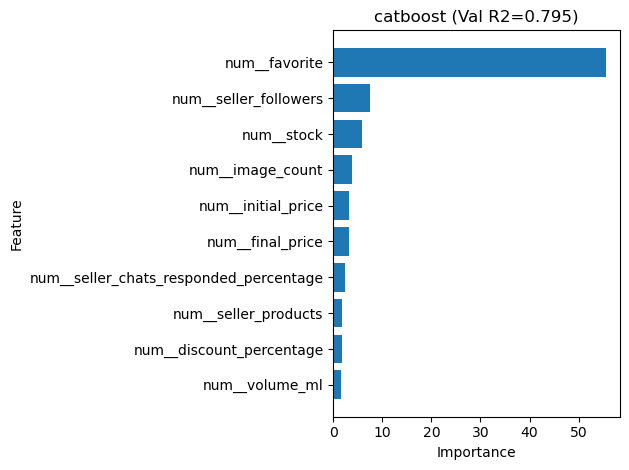

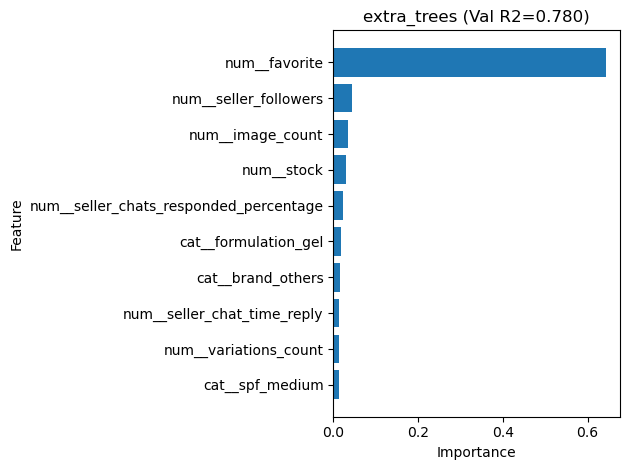

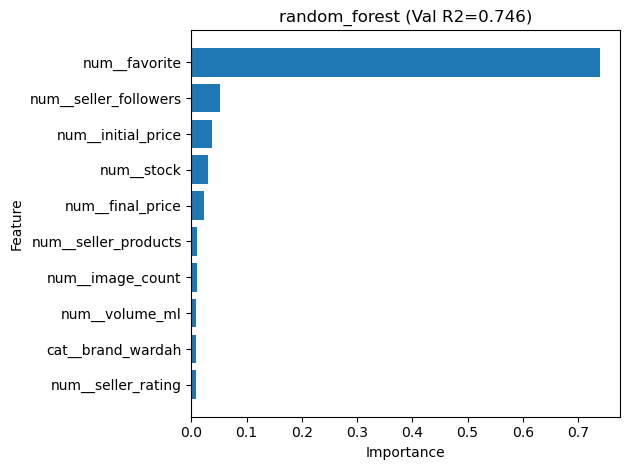


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite   19.878297
                 num__seller_followers    2.632424
                            num__stock    2.095562
                      num__image_count    1.351093
                    num__initial_price    1.111693
                      num__final_price    1.095528
num__seller_chats_responded_percentage    0.854801
                  num__seller_products    0.640408
              num__discount_percentage    0.618227
                        num__volume_ml    0.546775


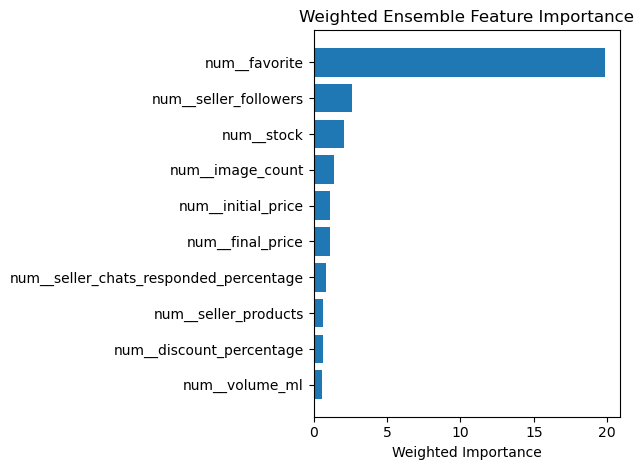


[STAGE] 11. FINAL MODEL SELECTION BY RMSE
        model stage_used  val_rmse  val_mae   val_r2
     ensemble   ensemble  0.392045 0.248038 0.800970
     catboost      tuned  0.398011 0.256460 0.794866
  extra_trees      tuned  0.412451 0.265039 0.779711
random_forest   baseline  0.442493 0.252046 0.746452
[INFO] Best final model selected by RMSE: ensemble
[INFO] Using retrained best individual model for SHAP: catboost

[STAGE] 11.5 RETRAIN FINAL MODEL ON TRAIN + VAL
[INFO] Final model retrained on train + val: ensemble

[STAGE] 12. SHAP ANALYSIS
[INFO] SHAP summary plot generating...


/var/folders/lt/sfjl1trs6n7996zzzjjjcyrw0000gn/T/ipykernel_83579/3970639357.py:428: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


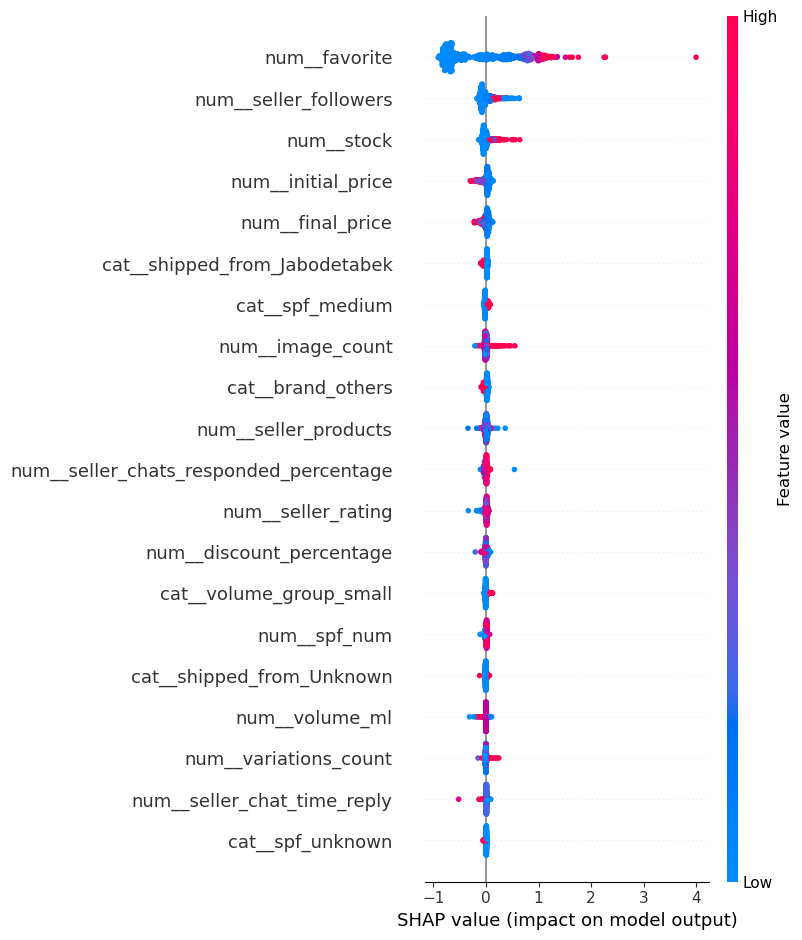


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature      positive_range       negative_range                             recommendation                                    interpretation                                insight
                         num__favorite    65.00 – 27340.00          0.00 – 1.00                          Increase favorite                       favorite ≈ 65.00 – 27340.00 higher values drive better performance
                 num__seller_followers   2.00 – 8156548.00    104.00 – 37300.00                  Increase seller_followers              seller_followers ≈ 2.00 – 8156548.00 higher values drive better performance
                            num__stock 43.00 – 24995859.00        0.00 – 324.00                             Increase stock                       stock ≈ 43.00 – 24995859.00 higher values drive better performance
                    num__initial_price 13000.00 – 85000.00 6000.00 – 1300000.00                       Reduce initial_pr

{'results_table':            model stage_used  val_rmse   val_mae    val_r2
 0       ensemble   ensemble  0.392045  0.248038  0.800970
 1       catboost      tuned  0.398011  0.256460  0.794866
 2    extra_trees      tuned  0.412451  0.265039  0.779711
 3  random_forest   baseline  0.442493  0.252046  0.746452,
 'best_model_name': 'ensemble',
 'final_model': {'type': 'ensemble',
  'member_models': [Pipeline(steps=[('prep',
                    ColumnTransformer(transformers=[('num',
                                                     Pipeline(steps=[('imputer',
                                                                      SimpleImputer(strategy='median'))]),
                                                     ['final_price',
                                                      'initial_price', 'stock',
                                                      'favorite',
                                                      'seller_followers',
                                    

In [232]:
df_sunscreen = df_sunscreen.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_sunscreen)

## SANDAL MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (6000, 44)
[INFO] Validation shape: (2000, 44)
[INFO] Test shape: (2000, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.72224371 0.69079298]
[INFO] Weight STD: [0.02371377 0.02463202]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 51.11% ± 1.68%
[INFO] z_rating_credibility: 48.89% ± 1.74%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.722244    0.023714   51.112877 1.678213
z_rating_credibility    0.690793    0.024632   48.887123 1.743197

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 32

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 20
[INFO] # Categorical: 9
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']

[DE

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.642099    0.011354     0.449239    0.730289
         lightgbm      0.660997    0.015196     0.458091    0.713891
          xgboost      0.683800    0.020544     0.468930    0.694133
      extra_trees      0.694656    0.014773     0.478624    0.684918
    random_forest      0.701411    0.011201     0.481586    0.678784
            ridge      0.747661    0.036850     0.497963    0.634244
linear_regression      0.748820    0.037510     0.497330    0.633039
      elastic_net      1.140611    0.035159     0.840322    0.152565
            lasso      1.239527    0.035432     0.928885   -0.000910
[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-26 01:35:36,384] Trial 0 finished with value: 0.6675148598570431 and parameters: {'iterations': 425, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 0.6675148598570431.
[I 2026-04-26 01:35:37,067] Trial 1 finished with value: 0.6897533105140872 and parameters: {'iterations': 293, 'depth': 4, 'learning_rate': 0.13394334706750485, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 0 with value: 0.6675148598570431.
[I 2026-04-26 01:35:39,039] Trial 2 finished with value: 0.6753900362256602 and parameters: {'iterations': 212, 'depth': 10, 'learning_rate': 0.12106896936002161, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 0 with value: 0.6675148598570431.
[I 2026-04-26 01:35:40,003] Trial 3 finished with value: 0.7007587933184842 and parameters: {'iterations': 310, 'depth': 6, 'learning_rate': 0.048164145309070844, 'l2_leaf_reg': 4.887505167779042, 'bord

[INFO] Best params for catboost: {'iterations': 800, 'depth': 8, 'learning_rate': 0.09363294362110128, 'l2_leaf_reg': 3.2305700597992484, 'border_count': 229}


...

[INFO] Best params for xgboost: {'n_estimators': 591, 'max_depth': 6, 'learning_rate': 0.07320421924905224, 'subsample': 0.6761911242955551, 'colsample_bytree': 0.8927883620622051, 'gamma': 0.023995665267347865, 'reg_lambda': 6.531514727811651}

Tuning Summary:
   model                                                                                                                                                                                                          best_params
catboost                                                                                        {'iterations': 800, 'depth': 8, 'learning_rate': 0.09363294362110128, 'l2_leaf_reg': 3.2305700597992484, 'border_count': 229}
lightgbm                               {'n_estimators': 682, 'num_leaves': 62, 'learning_rate': 0.03927335847790677, 'feature_fraction': 0.6629730352278201, 'bagging_fraction': 0.7935341909322308, 'min_child_samples': 10}
 xgboost {'n_estimators': 591, 'max_depth': 6, 'learning_rate': 0.073204

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

[INFO] lightgbm → using tuned model


/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] Processing: xgboost
[INFO] xgboost → using tuned model

[STAGE] STAGE 1 vs STAGE 2 COMPARISON + VALIDATION PERFORMANCE
   model  baseline_cv_rmse  baseline_cv_rmse_sd  tuned_cv_rmse  tuned_cv_rmse_sd stage_used  val_rmse  val_mae   val_r2
catboost          0.642099             0.011354       0.630472          0.012182      tuned  0.602399 0.422343 0.755978
lightgbm          0.660997             0.015196       0.625635          0.011671      tuned  0.599862 0.416179 0.758029
 xgboost          0.683800             0.020544       0.640896          0.006027      tuned  0.612115 0.428691 0.748043

[STAGE] TOP MODELS FEATURE IMPORTANCE


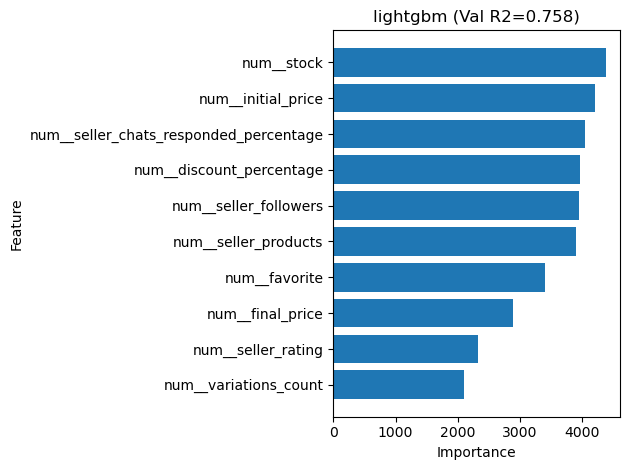

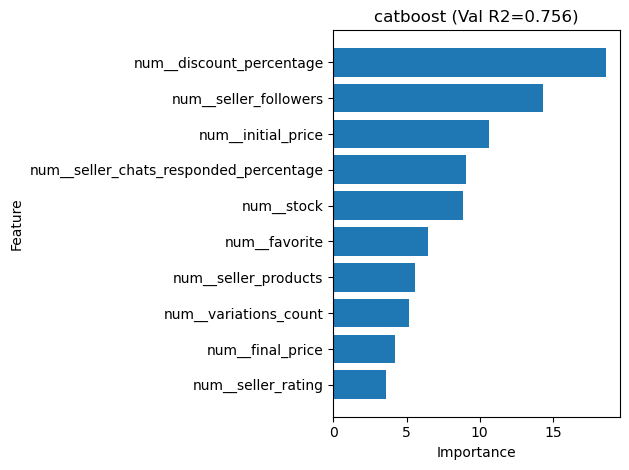

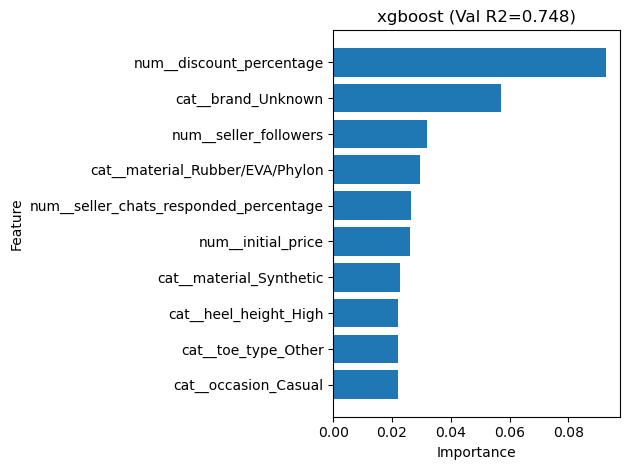


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                            num__stock 1476.196065
                    num__initial_price 1415.642811
num__seller_chats_responded_percentage 1361.681076
              num__discount_percentage 1334.999432
                 num__seller_followers 1330.508016
                  num__seller_products 1313.128266
                         num__favorite 1146.063405
                      num__final_price  970.574511
                    num__seller_rating  784.197402
                 num__variations_count  707.776721


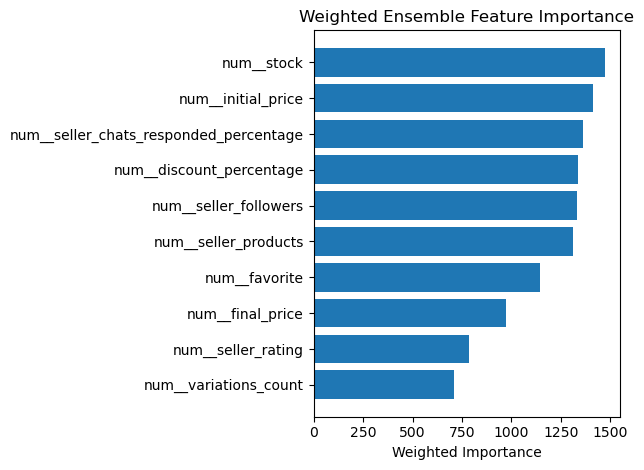


[STAGE] 11. FINAL MODEL SELECTION BY RMSE
   model stage_used  val_rmse  val_mae   val_r2
ensemble   ensemble  0.591047 0.413330 0.765089
lightgbm      tuned  0.599862 0.416179 0.758029
catboost      tuned  0.602399 0.422343 0.755978
 xgboost      tuned  0.612115 0.428691 0.748043
[INFO] Best final model selected by RMSE: ensemble
[INFO] Using retrained best individual model for SHAP: lightgbm

[STAGE] 11.5 RETRAIN FINAL MODEL ON TRAIN + VAL
[INFO] Final model retrained on train + val: ensemble

[STAGE] 12. SHAP ANALYSIS


 96%|=================== | 956/1000 [00:16<00:00]       

[INFO] SHAP summary plot generating...


/var/folders/lt/sfjl1trs6n7996zzzjjjcyrw0000gn/T/ipykernel_83579/3970639357.py:428: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


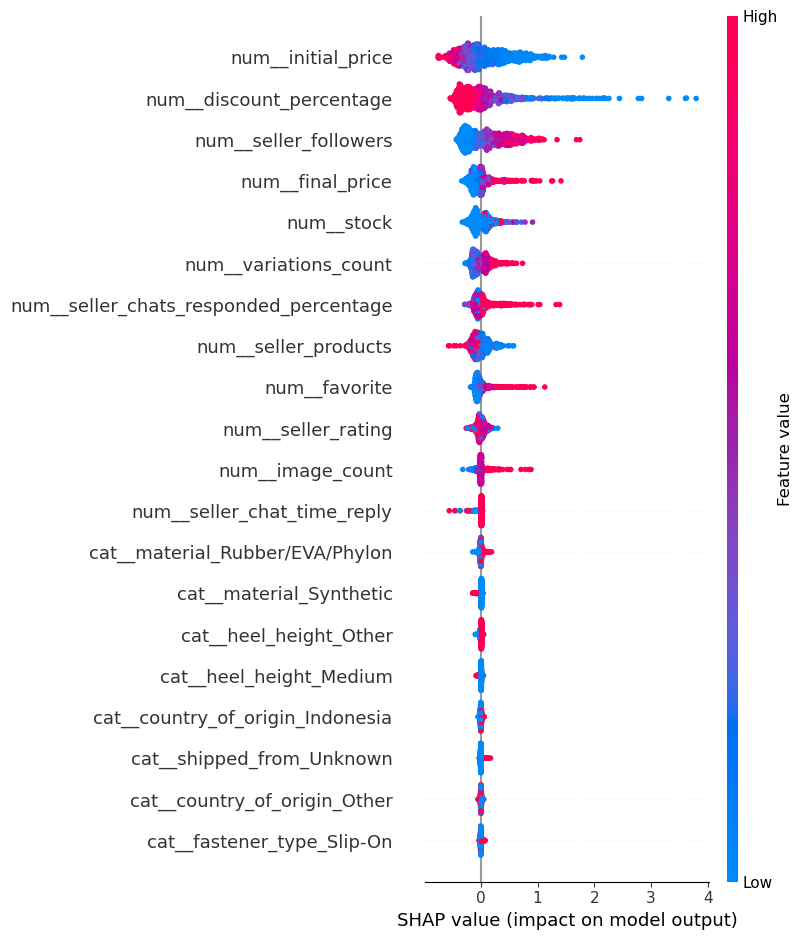


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature        positive_range         negative_range                             recommendation                                     interpretation                                insight
                    num__initial_price    8000.00 – 53999.00 100000.00 – 4984847.89                       Reduce initial_price                 initial_price ≈ 8000.00 – 53999.00  lower values drive better performance
              num__discount_percentage       -590.02 – 13.48          84.00 – 98.68                 Reduce discount_percentage              discount_percentage ≈ -590.02 – 13.48  lower values drive better performance
                 num__seller_followers 163097.28 – 424282.40        0.00 – 13583.84                  Increase seller_followers           seller_followers ≈ 163097.28 – 424282.40 higher values drive better performance
                      num__final_price  9395.44 – 1060501.58    2000.00 – 195261.20                

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


                          feature  current_typical_value recommended_target_or_range  best_predicted_bin_mean                                    note
                    initial_price             80000.0000               5000 to 3e+04                 0.191245 Optimal range based on model prediction
              discount_percentage                50.1382            -609.9 to -73.03                 1.406198 Optimal range based on model prediction
                 seller_followers            109372.6081      2.768e+05 to 4.243e+05                 1.135196 Optimal range based on model prediction
                      final_price             48248.8414      2.618e+05 to 1.216e+06                 0.599807 Optimal range based on model prediction
                            stock                73.0000               559.6 to 2388                 0.364837 Optimal range based on model prediction
                 variations_count                 9.0000                    13 to 50                

{'results_table':       model stage_used  val_rmse   val_mae    val_r2
 0  ensemble   ensemble  0.591047  0.413330  0.765089
 1  lightgbm      tuned  0.599862  0.416179  0.758029
 2  catboost      tuned  0.602399  0.422343  0.755978
 3   xgboost      tuned  0.612115  0.428691  0.748043,
 'best_model_name': 'ensemble',
 'final_model': {'type': 'ensemble',
  'member_models': [Pipeline(steps=[('prep',
                    ColumnTransformer(transformers=[('num',
                                                     Pipeline(steps=[('imputer',
                                                                      SimpleImputer(strategy='median'))]),
                                                     ['final_price',
                                                      'initial_price', 'stock',
                                                      'favorite',
                                                      'seller_followers',
                                                      'seller

In [233]:
df_sandal = df_sandal.drop(columns=["seller_joined_date", "breadcrumb", "discount"], errors="ignore")
run_pipeline(df_sandal)

## WALLET MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2490, 47)
[INFO] Validation shape: (830, 47)
[INFO] Test shape: (831, 47)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.70194362 0.71140773]
[INFO] Weight STD: [0.02443026 0.02402841]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 49.67% ± 1.73%
[INFO] z_rating_credibility: 50.33% ± 1.70%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.701944    0.024430   49.665189 1.728534
z_rating_credibility    0.711408    0.024028   50.334811 1.700102

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 35

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 13
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_tim

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.758800    0.036056     0.451717    0.610422
         lightgbm      0.770330    0.041769     0.457022    0.597886
      extra_trees      0.795247    0.035837     0.456363    0.572129
    random_forest      0.796059    0.035671     0.455658    0.571686
          xgboost      0.810359    0.037902     0.473678    0.555570
            ridge      0.931556    0.024838     0.643683    0.416453
linear_regression      0.933578    0.025417     0.644837    0.413926
      elastic_net      1.176296    0.047815     0.902038    0.071226
            lasso      1.222755    0.044835     0.957263   -0.003855
[INFO] Top models: ['catboost', 'lightgbm', 'extra_trees']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-26 09:29:45,735] Trial 0 finished with value: 0.769756591676664 and parameters: {'iterations': 425, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 0.769756591676664.
[I 2026-04-26 09:29:46,194] Trial 1 finished with value: 0.7932354059048048 and parameters: {'iterations': 293, 'depth': 4, 'learning_rate': 0.13394334706750485, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 0 with value: 0.769756591676664.
[I 2026-04-26 09:29:47,767] Trial 2 finished with value: 0.7719273146760951 and parameters: {'iterations': 212, 'depth': 10, 'learning_rate': 0.12106896936002161, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 0 with value: 0.769756591676664.
[I 2026-04-26 09:29:48,451] Trial 3 finished with value: 0.7831587505215447 and parameters: {'iterations': 310, 'depth': 6, 'learning_rate': 0.048164145309070844, 'l2_leaf_reg': 4.887505167779042, 'border_c

[INFO] Best params for catboost: {'iterations': 532, 'depth': 8, 'learning_rate': 0.07033561396304945, 'l2_leaf_reg': 4.064949844098575, 'border_count': 32}


...

[INFO] Best params for extra_trees: {'n_estimators': 184, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 2}

Tuning Summary:
      model                                                                                                                                                                            best_params
   catboost                                                            {'iterations': 532, 'depth': 8, 'learning_rate': 0.07033561396304945, 'l2_leaf_reg': 4.064949844098575, 'border_count': 32}
   lightgbm {'n_estimators': 755, 'num_leaves': 51, 'learning_rate': 0.017495321029891413, 'feature_fraction': 0.6427496508021312, 'bagging_fraction': 0.6660090687885312, 'min_child_samples': 7}
extra_trees                                                                                                  {'n_estimators': 184, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 2}

[STAGE] 9. FINALIZE TOP MODELS (VALIDATION-BASED)
[INFO] Processing: catboost
[I

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

[INFO] lightgbm → using tuned model


/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] Processing: extra_trees
[INFO] extra_trees → using tuned model

[STAGE] STAGE 1 vs STAGE 2 COMPARISON + VALIDATION PERFORMANCE
      model  baseline_cv_rmse  baseline_cv_rmse_sd  tuned_cv_rmse  tuned_cv_rmse_sd stage_used  val_rmse  val_mae   val_r2
   catboost          0.758800             0.036056       0.750561          0.047143      tuned  0.793473 0.462770 0.592752
   lightgbm          0.770330             0.041769       0.748035          0.036048      tuned  0.785304 0.452380 0.601094
extra_trees          0.795247             0.035837       0.784913          0.038034      tuned  0.802724 0.456042 0.583201

[STAGE] TOP MODELS FEATURE IMPORTANCE


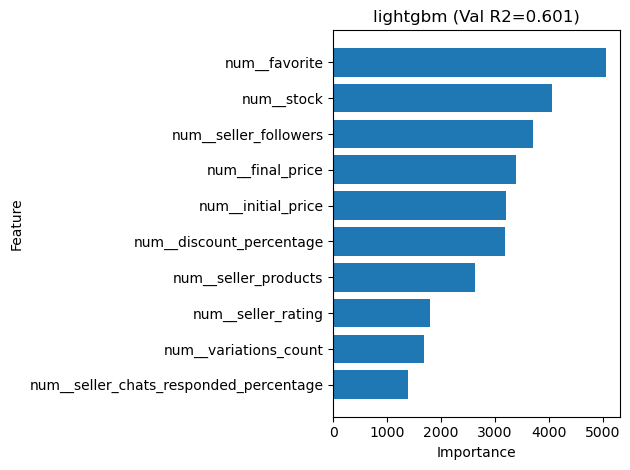

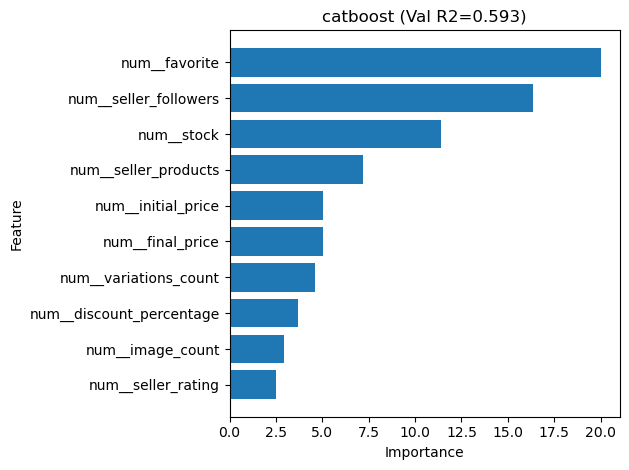

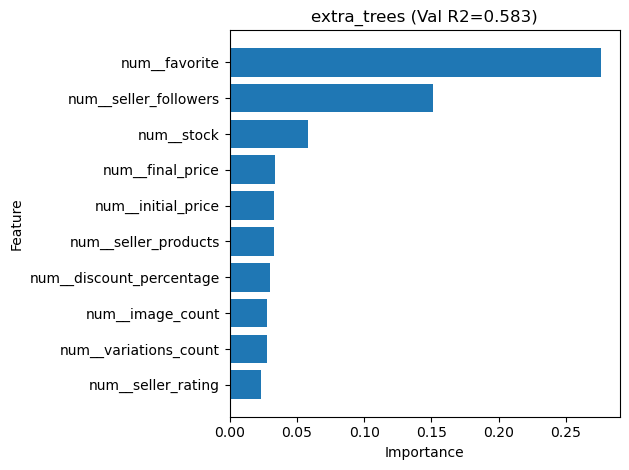


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite 1714.318842
                            num__stock 1372.072474
                 num__seller_followers 1253.809782
                      num__final_price 1145.892084
                    num__initial_price 1079.181197
              num__discount_percentage 1076.378235
                  num__seller_products  887.175228
                    num__seller_rating  604.950307
                 num__variations_count  571.631268
num__seller_chats_responded_percentage  470.832049


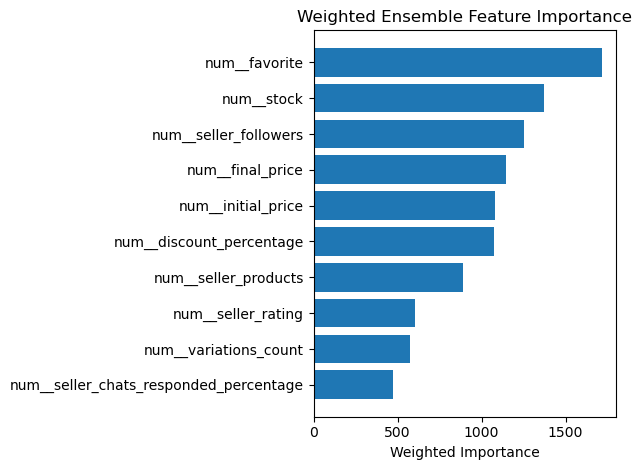


[STAGE] 11. FINAL MODEL SELECTION BY RMSE
      model stage_used  val_rmse  val_mae   val_r2
   ensemble   ensemble  0.776139 0.444750 0.610351
   lightgbm      tuned  0.785304 0.452380 0.601094
   catboost      tuned  0.793473 0.462770 0.592752
extra_trees      tuned  0.802724 0.456042 0.583201
[INFO] Best final model selected by RMSE: ensemble
[INFO] Using retrained best individual model for SHAP: lightgbm

[STAGE] 11.5 RETRAIN FINAL MODEL ON TRAIN + VAL
[INFO] Final model retrained on train + val: ensemble

[STAGE] 12. SHAP ANALYSIS


 96%|=================== | 797/830 [00:20<00:00]       /var/folders/lt/sfjl1trs6n7996zzzjjjcyrw0000gn/T/ipykernel_83579/3970639357.py:428: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


[INFO] SHAP summary plot generating...


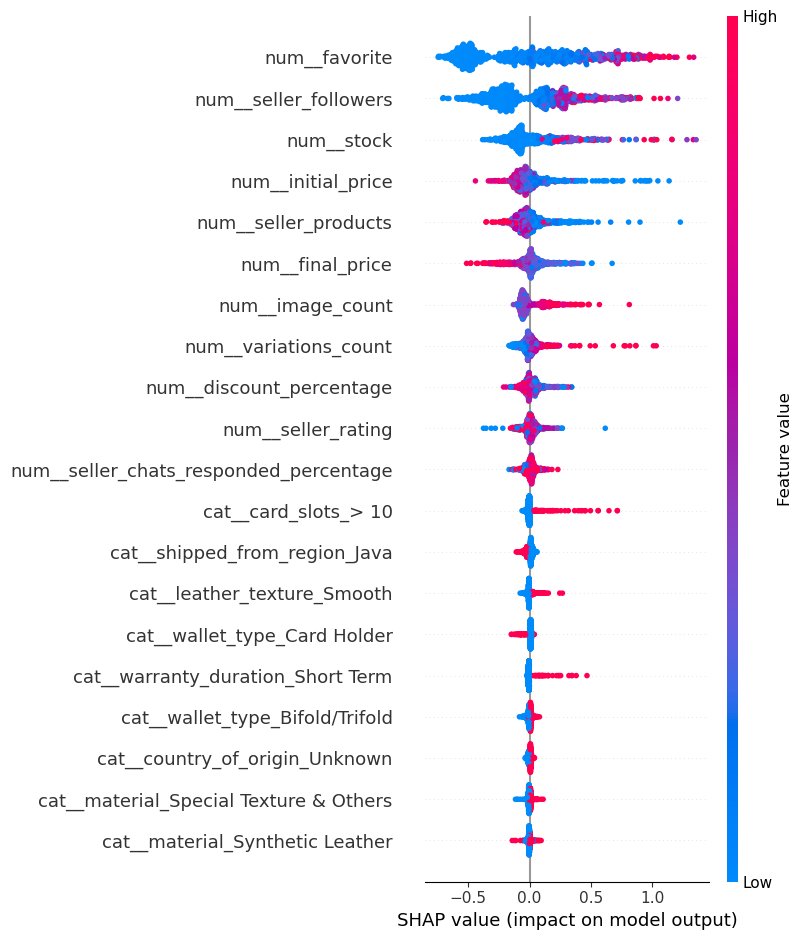


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature      positive_range       negative_range                             recommendation                                     interpretation                                insight
                         num__favorite      29.00 – 997.00         0.00 – 12.00                          Increase favorite                          favorite ≈ 29.00 – 997.00 higher values drive better performance
                 num__seller_followers   14.00 – 793800.00     20.00 – 26700.00                  Increase seller_followers               seller_followers ≈ 14.00 – 793800.00 higher values drive better performance
                            num__stock     0.00 – 24899.00        0.00 – 234.00                             Increase stock                            stock ≈ 0.00 – 24899.00 higher values drive better performance
                    num__initial_price 7999.00 – 609000.00 99000.00 – 759000.00                       Reduce initia

/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'results_table':          model stage_used  val_rmse   val_mae    val_r2
 0     ensemble   ensemble  0.776139  0.444750  0.610351
 1     lightgbm      tuned  0.785304  0.452380  0.601094
 2     catboost      tuned  0.793473  0.462770  0.592752
 3  extra_trees      tuned  0.802724  0.456042  0.583201,
 'best_model_name': 'ensemble',
 'final_model': {'type': 'ensemble',
  'member_models': [Pipeline(steps=[('prep',
                    ColumnTransformer(transformers=[('num',
                                                     Pipeline(steps=[('imputer',
                                                                      SimpleImputer(strategy='median'))]),
                                                     ['final_price',
                                                      'initial_price', 'stock',
                                                      'favorite',
                                                      'seller_followers',
                                              

In [234]:
df_wallet = df_wallet.drop(columns=["seller_joined_date", "breadcrumb", "discount", "log_gmv"], errors="ignore")
run_pipeline(df_wallet)

## PAN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2730, 42)
[INFO] Validation shape: (910, 42)
[INFO] Test shape: (911, 42)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.81140959 0.48775211]
[INFO] Weight STD: [0.20433946 0.24891311]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 62.46% ± 15.73%
[INFO] z_rating_credibility: 37.54% ± 19.16%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.811410    0.204339   62.456397 15.728562
z_rating_credibility    0.487752    0.248913   37.543603 19.159517

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 30

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 20
[INFO] # Categorical: 8
[INFO] # Binary: 2

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']



/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/clean-ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.912058    0.224036     0.468031    0.282172
          xgboost      0.917240    0.253601     0.473238    0.239699
    random_forest      0.935199    0.220795     0.465413    0.231821
         lightgbm      0.995076    0.279013     0.489408    0.175010
      extra_trees      1.041806    0.266196     0.500850    0.098938
            ridge      1.086015    0.324054     0.596412    0.058000
linear_regression      1.092797    0.319274     0.602339    0.041491
            lasso      1.128353    0.351554     0.654857   -0.003662
      elastic_net      1.128353    0.351554     0.654857   -0.003662
[INFO] Top models: ['catboost', 'xgboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-26 11:53:26,198] Trial 0 finished with value: 0.8871865423382207 and parameters: {'iterations': 425, 'depth': 10, 'learning_rate': 0.08960785365368121, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 0.8871865423382207.
[I 2026-04-26 11:53:27,246] Trial 1 finished with value: 0.9373726983934393 and parameters: {'iterations': 293, 'depth': 4, 'learning_rate': 0.13394334706750485, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 0 with value: 0.8871865423382207.
[I 2026-04-26 11:53:31,271] Trial 2 finished with value: 0.8863385611954337 and parameters: {'iterations': 212, 'depth': 10, 'learning_rate': 0.12106896936002161, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 2 with value: 0.8863385611954337.
[I 2026-04-26 11:53:32,842] Trial 3 finished with value: 0.9070629221597619 and parameters: {'iterations': 310, 'depth': 6, 'learning_rate': 0.048164145309070844, 'l2_leaf_reg': 4.887505167779042, 'bord

[INFO] Best params for catboost: {'iterations': 416, 'depth': 7, 'learning_rate': 0.14586892648717636, 'l2_leaf_reg': 6.748168747800293, 'border_count': 137}


...

[INFO] Best params for xgboost: {'n_estimators': 779, 'max_depth': 8, 'learning_rate': 0.07759306055508468, 'subsample': 0.7387431740008915, 'colsample_bytree': 0.8615772513341808, 'gamma': 0.8337743761741703, 'reg_lambda': 0.049457998062356914}


[I 2026-04-26 12:02:27,570] A new study created in memory with name: no-name-14cbaa1d-a6c2-4c36-9508-b4a76c6ceb4f


[INFO] Tuning model: random_forest


[I 2026-04-26 12:02:29,546] Trial 0 finished with value: 0.9747182601444002 and parameters: {'n_estimators': 212, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9747182601444002.
[I 2026-04-26 12:02:30,096] Trial 1 finished with value: 1.0397924030380383 and parameters: {'n_estimators': 117, 'max_depth': 27, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9747182601444002.
[I 2026-04-26 12:02:31,709] Trial 2 finished with value: 1.0046326993463823 and parameters: {'n_estimators': 350, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.9747182601444002.
[I 2026-04-26 12:02:33,000] Trial 3 finished with value: 0.9979368690765652 and parameters: {'n_estimators': 230, 'max_depth': 12, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.97471826014440

[INFO] Best params for random_forest: {'n_estimators': 186, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model                                                                                                                                                                                                           best_params
     catboost                                                                                          {'iterations': 416, 'depth': 7, 'learning_rate': 0.14586892648717636, 'l2_leaf_reg': 6.748168747800293, 'border_count': 137}
      xgboost {'n_estimators': 779, 'max_depth': 8, 'learning_rate': 0.07759306055508468, 'subsample': 0.7387431740008915, 'colsample_bytree': 0.8615772513341808, 'gamma': 0.8337743761741703, 'reg_lambda': 0.049457998062356914}
random_forest                                                                                                         {'n_estimators': 186, 'max_depth'

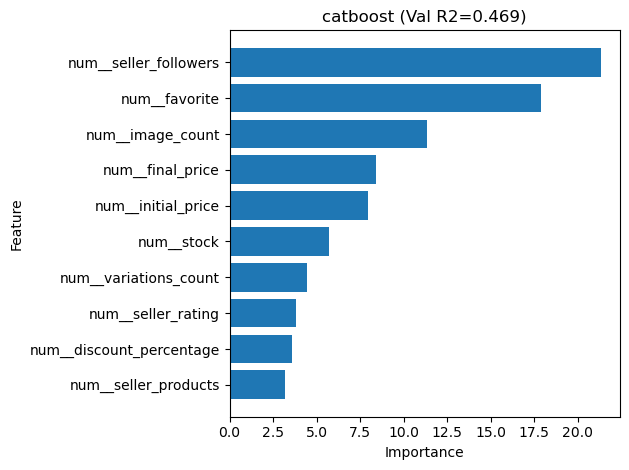

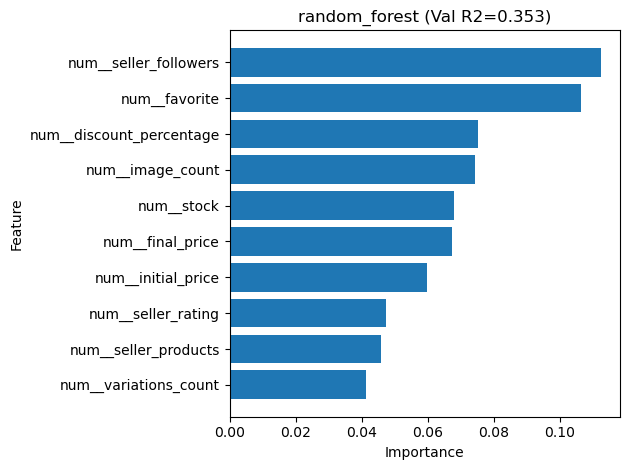

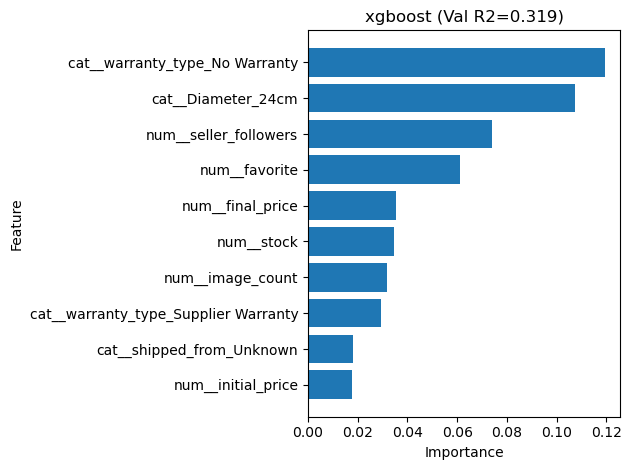


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                 feature  importance
   num__seller_followers    7.712729
           num__favorite    6.456205
        num__image_count    4.088688
        num__final_price    3.042802
      num__initial_price    2.882693
              num__stock    2.084832
   num__variations_count    1.608594
      num__seller_rating    1.390091
num__discount_percentage    1.309027
    num__seller_products    1.149859


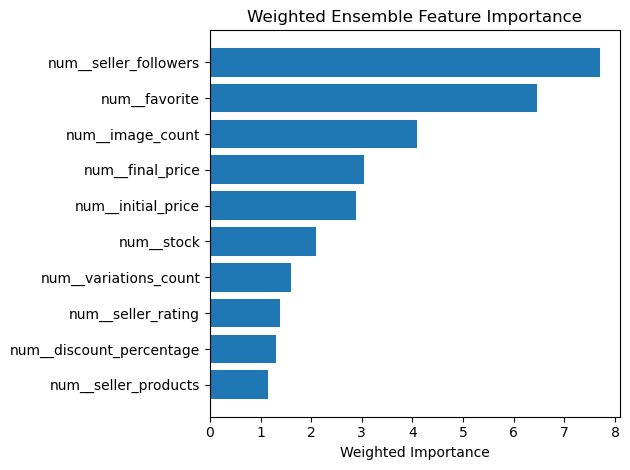


[STAGE] 11. FINAL MODEL SELECTION BY RMSE
        model stage_used  val_rmse  val_mae   val_r2
     catboost      tuned  0.512098 0.406290 0.468598
     ensemble   ensemble  0.521167 0.414616 0.449610
random_forest      tuned  0.565265 0.450942 0.352529
      xgboost      tuned  0.579785 0.416015 0.318836
[INFO] Best final model selected by RMSE: catboost

[STAGE] 11.5 RETRAIN FINAL MODEL ON TRAIN + VAL
[INFO] Final model retrained on train + val: catboost

[STAGE] 12. SHAP ANALYSIS
[INFO] SHAP summary plot generating...


/var/folders/lt/sfjl1trs6n7996zzzjjjcyrw0000gn/T/ipykernel_83579/3970639357.py:428: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)


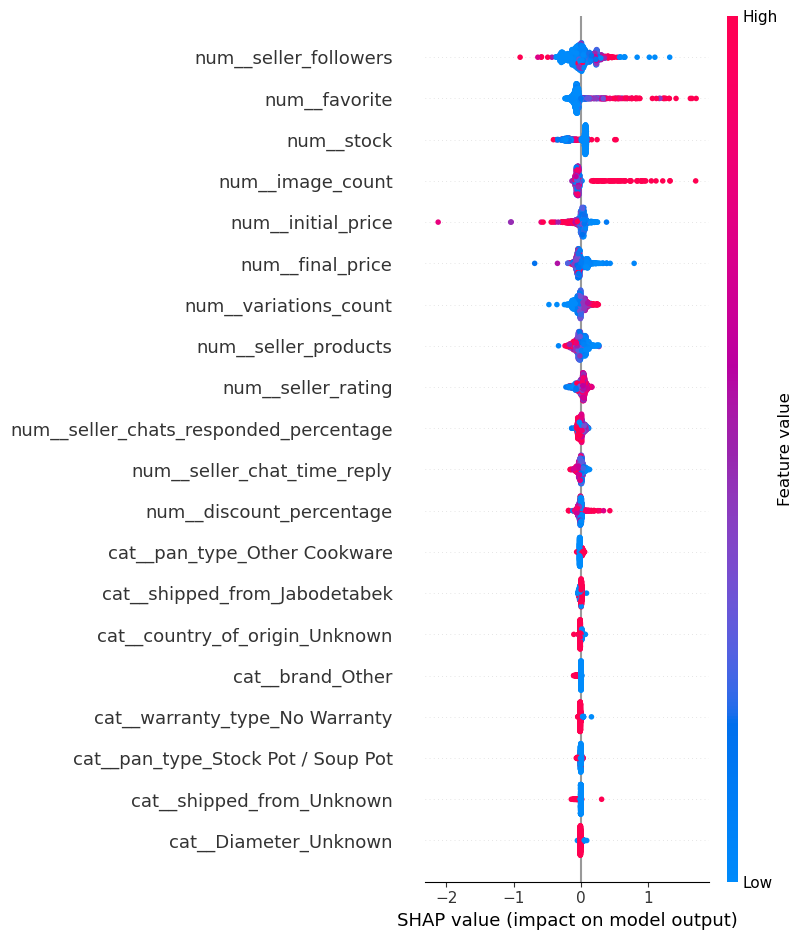


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature      positive_range        negative_range                           recommendation                                    interpretation                                insight
                 num__seller_followers   2.00 – 4136968.00      0.00 – 970000.00                Increase seller_followers              seller_followers ≈ 2.00 – 4136968.00 higher values drive better performance
                         num__favorite      0.00 – 4938.00          0.00 – 41.00                        Increase favorite                         favorite ≈ 0.00 – 4938.00 higher values drive better performance
                            num__stock     0.00 – 32955.00       2.00 – 17797.00                             Reduce stock                           stock ≈ 0.00 – 32955.00  lower values drive better performance
                      num__image_count        1.00 – 17.00           1.00 – 9.00                     Increase image_count  

{'results_table':            model stage_used  val_rmse   val_mae    val_r2
 0       catboost      tuned  0.512098  0.406290  0.468598
 1       ensemble   ensemble  0.521167  0.414616  0.449610
 2  random_forest      tuned  0.565265  0.450942  0.352529
 3        xgboost      tuned  0.579785  0.416015  0.318836,
 'best_model_name': 'catboost',
 'final_model': Pipeline(steps=[('prep',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['final_price',
                                                    'initial_price', 'stock',
                                                    'favorite',
                                                    'seller_followers',
                                                    'seller_products',
                    

In [235]:
df_pan = df_pan.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_pan)